In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


In [2]:
# This is the official implementation of the single-phase model for multi-class CVD classification presented in:
# Srikijkasemwat N, Villarroel M, Banerjee A,
# "Multi-Phase Deep Learning Model for Automated Disease Classification from Cardiac Cine MRI",
# Journal of the Royal Society Interface, 2025.
# Author: Srikijkasemwat N
# Date : August 27, 2025
#
# The training code based on:
# Chilamkurthy, S. "Transfer Learning for Computer Vision Tutorial."
# PyTorch Tutorials, https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
# Accessed November 2023.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
cudnn.benchmark = True
from torchvision.io.image import read_image
from torchvision.transforms.functional import normalize, resize, to_pil_image

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if mid_channels is None:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(
                in_channels, in_channels // 2, kernel_size=2, stride=2
            )
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)

        x1 = F.pad(
            x1,
            [diffX // 2, diffX - diffX // 2,
             diffY // 2, diffY - diffY // 2]
        )

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, bilinear=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)

        self.outc = OutConv(64, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)

### 1. Data Preparation for Single-Phase Cardiac MRI Classification  
**Mid-Cavity Slice Selection and Heart-Centred First Crop**

This section prepares the ACDC cardiac cine MRI data for classification.  
The workflow identifies the mid-cavity short-axis slice, localizes the heart using the segmentation mask, computes the heart centre, and defines a larger first crop around the heart.

The maximum heart height and width are computed from the training set only.  
These values are then used to define a first crop enlarged by a factor of 1.5, which helps preserve the cardiac region during later rotation-based augmentation.

In [4]:
import os
import json
import numpy as np
import nibabel as nib
from pathlib import Path
import torch
import torch.nn.functional as F

# ============================================================
# CONFIG
# ============================================================
ACDC_ROOT = r"C:\Users\manoj\Desktop\Thesis\ACDC\ACDC\database"
TRAIN_DIR = os.path.join(ACDC_ROOT, "training")
TEST_DIR = os.path.join(ACDC_ROOT, "testing")

# SAFE STRICT ROOT (separate from previous segmented project)
STRICT_ES_ROOT = Path(r"C:\Users\manoj\Desktop\Thesis\ES_segmented_project_strict_mirror_v5")
STRICT_ES_ROOT.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = STRICT_ES_ROOT / "cache_es_segmented_strict_v5"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

CKPT_DIR = STRICT_ES_ROOT / "checkpoints_ES_segmented_strict_v5"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = STRICT_ES_ROOT / "figures_ES_segmented_strict_v5"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = STRICT_ES_ROOT / "tables_ES_segmented_strict_v5"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

META_DIR = STRICT_ES_ROOT / "meta_ES_segmented_strict_v5"
META_DIR.mkdir(parents=True, exist_ok=True)

SEG_EXPERIMENT_DIR = Path(
    r"C:\Users\manoj\Desktop\Thesis\16873796\runs_acdc_segmentation_experiments\unet_main_aug_fg_2slice_20260312_180315"
)

SEG_NET_INPUT_SIZE = 256
SEG_CROP_MARGIN = 10

CLASS_MAP = {
    "NOR": "NOR",
    "MINF": "MI",
    "DCM": "DCM",
    "HCM": "HCM",
    "RV": "ARV",
}

CLASS_TO_IDX = {
    "ARV": 0,
    "DCM": 1,
    "HCM": 2,
    "MI": 3,
    "NOR": 4,
}

CLASS_NAMES = ["ARV", "DCM", "HCM", "MI", "NOR"]

# ============================================================
# FIXED FOLDS (same as original ES notebook)
# ============================================================
train_ids_fold0 = [1,2,3,4,5,7,8,9,10,11,12,13,15,18,19,21,22,25,26,27,28,29,30,31,32,33,35,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,58,60,61,65,66,67,68,69,71,72,73,74,75,76,77,78,80,81,82,83,84,85,86,87,88,89,90,92,94,96,97]
val_ids_fold0   = [0,6,14,16,17,20,23,24,34,36,50,51,56,57,59,62,63,64,70,79,91,93,95,98,99]

train_ids_fold1 = [0,1,2,4,6,7,8,9,10,11,12,14,16,17,18,20,21,22,23,24,25,26,27,28,31,33,34,35,36,37,40,41,42,43,44,45,48,49,50,51,55,56,57,58,59,62,63,64,65,66,67,68,70,71,72,73,74,76,77,79,83,84,85,87,88,90,91,92,93,94,95,96,97,98,99]
val_ids_fold1   = [3,5,13,15,19,29,30,32,38,39,46,47,52,53,54,60,61,69,75,78,80,81,82,86,89]

train_ids_fold2 = [0,1,3,5,6,7,8,10,13,14,15,16,17,18,19,20,23,24,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,46,47,48,49,50,51,52,53,54,56,57,59,60,61,62,63,64,65,66,68,69,70,72,74,75,78,79,80,81,82,85,86,89,90,91,92,93,94,95,96,98,99]
val_ids_fold2   = [2,4,9,11,12,21,22,25,26,27,43,44,45,55,58,67,71,73,76,77,83,84,87,88,97]

train_ids_fold3 = [0,2,3,4,5,6,9,11,12,13,14,15,16,17,19,20,21,22,23,24,25,26,27,29,30,32,34,36,38,39,43,44,45,46,47,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,67,69,70,71,73,75,76,77,78,79,80,81,82,83,84,86,87,88,89,91,93,95,97,98,99]
val_ids_fold3   = [1,7,8,10,18,28,31,33,35,37,40,41,42,48,49,65,66,68,72,74,85,90,92,94,96]

train_ids_fold = [train_ids_fold0, train_ids_fold1, train_ids_fold2, train_ids_fold3]
val_ids_fold   = [val_ids_fold0,   val_ids_fold1,   val_ids_fold2,   val_ids_fold3]

# ============================================================
# HELPERS
# ============================================================
def parse_cfg(cfg_path: str) -> dict:
    cfg = {}
    with open(cfg_path, "r", encoding="utf-8") as f:
        for line in f:
            if ":" in line:
                k, v = line.strip().split(":", 1)
                cfg[k.strip()] = v.strip()
    return cfg


def load_nii(path: str) -> np.ndarray:
    return nib.load(path).get_fdata()


def zscore(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def minmax_to_uint8(img_2d: np.ndarray) -> np.ndarray:
    x = img_2d.astype(np.float32)
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    x = (x * 255.0).clip(0, 255).astype(np.uint8)
    return x


def bbox_from_mask(mask_2d: np.ndarray):
    ys, xs = np.where(mask_2d > 0)
    if ys.size == 0:
        return None
    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())
    return y_min, y_max, x_min, x_max


def crop_bbox_with_margin(img_2d, mask_2d, margin=10):
    bb = bbox_from_mask(mask_2d)
    if bb is None:
        return img_2d, mask_2d

    y_min, y_max, x_min, x_max = bb
    H, W = img_2d.shape

    y1 = max(0, y_min - margin)
    y2 = min(H, y_max + margin + 1)
    x1 = max(0, x_min - margin)
    x2 = min(W, x_max + margin + 1)

    return img_2d[y1:y2, x1:x2], mask_2d[y1:y2, x1:x2]


@torch.no_grad()
def predict_segmentation_mask(model, img_2d: np.ndarray, img_size=256, device="cuda"):
    h, w = img_2d.shape

    x = torch.from_numpy(img_2d.astype(np.float32)).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    x = F.interpolate(x, size=(img_size, img_size), mode="bilinear", align_corners=False)
    x = x.to(device)

    logits = model(x)
    pred = torch.argmax(logits, dim=1, keepdim=True).float()   # [1,1,256,256]

    # resize mask back to original image shape
    pred = F.interpolate(pred, size=(h, w), mode="nearest")
    pred = pred[0, 0].cpu().numpy().astype(np.uint8)

    return pred


# ============================================================
# BUILD FOLD-SPECIFIC STRICT SEGMENTED ES CACHE
# ============================================================
for fold in range(4):
    print(f"\n{'='*80}")
    print(f"BUILDING STRICT SEGMENTED ES CACHE - FOLD {fold}")
    print(f"{'='*80}")

    fold_root = CACHE_ROOT / f"fold_{fold:02d}"
    fold_root.mkdir(parents=True, exist_ok=True)

    ckpt_path = SEG_EXPERIMENT_DIR / f"fold_{fold:02d}" / f"unet_main_aug_fg_2slice_best_fold{fold}.pth"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing U-Net checkpoint: {ckpt_path}")

    seg_model = UNet(in_channels=1, out_channels=4, bilinear=False).to(device)
    ckpt = torch.load(ckpt_path, map_location=device)
    seg_model.load_state_dict(ckpt["model_state"])
    seg_model.eval()

    train_records = []
    test_records = []

    train_all_ids = train_ids_fold[fold] + val_ids_fold[fold]

    # ---------------- TRAIN_ALL ----------------
    for pid0 in train_all_ids:
        patient = f"patient{pid0 + 1:03d}"
        patient_dir = Path(TRAIN_DIR) / patient

        cfg = parse_cfg(str(patient_dir / "Info.cfg"))
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        es = int(cfg["ES"])
        es_img_path = patient_dir / f"{patient}_frame{es:02d}.nii.gz"
        es_vol = load_nii(str(es_img_path))

        best_slice = None
        best_area = -1
        best_crop = None

        for z in range(es_vol.shape[2]):
            img2d = zscore(es_vol[:, :, z])
            pred_mask = predict_segmentation_mask(seg_model, img2d, img_size=SEG_NET_INPUT_SIZE, device=device)
            fg = (pred_mask > 0).astype(np.uint8)
            area = int(fg.sum())

            if area > best_area:
                best_area = area
                seg_img = img2d * fg
                crop_img, _ = crop_bbox_with_margin(seg_img, fg, margin=SEG_CROP_MARGIN)
                best_crop = crop_img.astype(np.float32)
                best_slice = z

        save_dir = fold_root / "train_all" / patient
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / "ES_segmented.npy"
        np.save(save_path, best_crop)

        train_records.append({
            "split": "train_all",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "es_path": str(save_path),
            "best_slice": int(best_slice),
            "best_fg_area": int(best_area),
        })

    # ---------------- TEST ----------------
    for patient_dir in sorted(Path(TEST_DIR).iterdir()):
        if not patient_dir.is_dir() or not patient_dir.name.startswith("patient"):
            continue

        patient = patient_dir.name
        cfg = parse_cfg(str(patient_dir / "Info.cfg"))
        class_name = CLASS_MAP[cfg["Group"]]
        label = CLASS_TO_IDX[class_name]

        es = int(cfg["ES"])
        es_img_path = patient_dir / f"{patient}_frame{es:02d}.nii.gz"
        es_vol = load_nii(str(es_img_path))

        best_slice = None
        best_area = -1
        best_crop = None

        for z in range(es_vol.shape[2]):
            img2d = zscore(es_vol[:, :, z])
            pred_mask = predict_segmentation_mask(seg_model, img2d, img_size=SEG_NET_INPUT_SIZE, device=device)
            fg = (pred_mask > 0).astype(np.uint8)
            area = int(fg.sum())

            if area > best_area:
                best_area = area
                seg_img = img2d * fg
                crop_img, _ = crop_bbox_with_margin(seg_img, fg, margin=SEG_CROP_MARGIN)
                best_crop = crop_img.astype(np.float32)
                best_slice = z

        save_dir = fold_root / "test" / patient
        save_dir.mkdir(parents=True, exist_ok=True)
        save_path = save_dir / "ES_segmented.npy"
        np.save(save_path, best_crop)

        test_records.append({
            "split": "test",
            "patient": patient,
            "class_name": class_name,
            "label": label,
            "es_path": str(save_path),
            "best_slice": int(best_slice),
            "best_fg_area": int(best_area),
        })

    with open(fold_root / "cache_index_train_all.json", "w", encoding="utf-8") as f:
        json.dump(train_records, f, indent=2)

    with open(fold_root / "cache_index_test.json", "w", encoding="utf-8") as f:
        json.dump(test_records, f, indent=2)

    meta = {
        "fold": fold,
        "source": "strict mirror segmented ES cache v5",
        "checkpoint": str(ckpt_path),
        "crop_margin": SEG_CROP_MARGIN,
        "seg_input_size": SEG_NET_INPUT_SIZE,
    }
    with open(fold_root / "cache_meta_es_segmented_v5.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    print("Saved:", fold_root)

# ============================================================
# SAVE GLOBAL CACHE META FOR TRANSFORM CELL
# ============================================================
max_h = 0
max_w = 0

for fold in range(4):
    fold_root = CACHE_ROOT / f"fold_{fold:02d}"
    train_index_path = fold_root / "cache_index_train_all.json"

    with open(train_index_path, "r", encoding="utf-8") as f:
        train_records = json.load(f)

    for r in train_records:
        arr = np.load(r["es_path"])
        h, w = arr.shape
        max_h = max(max_h, h)
        max_w = max(max_w, w)

cache_meta = {
    "max_height": int(max_h),
    "max_width": int(max_w)
}

with open(CACHE_ROOT / "cache_meta.json", "w", encoding="utf-8") as f:
    json.dump(cache_meta, f, indent=2)

print("\nSaved global cache_meta.json")
print("Max height:", max_h)
print("Max width :", max_w)


BUILDING STRICT SEGMENTED ES CACHE - FOLD 0
Saved: C:\Users\manoj\Desktop\Thesis\ES_segmented_project_strict_mirror_v5\cache_es_segmented_strict_v5\fold_00

BUILDING STRICT SEGMENTED ES CACHE - FOLD 1
Saved: C:\Users\manoj\Desktop\Thesis\ES_segmented_project_strict_mirror_v5\cache_es_segmented_strict_v5\fold_01

BUILDING STRICT SEGMENTED ES CACHE - FOLD 2
Saved: C:\Users\manoj\Desktop\Thesis\ES_segmented_project_strict_mirror_v5\cache_es_segmented_strict_v5\fold_02

BUILDING STRICT SEGMENTED ES CACHE - FOLD 3
Saved: C:\Users\manoj\Desktop\Thesis\ES_segmented_project_strict_mirror_v5\cache_es_segmented_strict_v5\fold_03

Saved global cache_meta.json
Max height: 176
Max width : 195


### 2. Image Transformation pipeline


**Training Augmentation and Evaluation Preparation**

This section defines the transformation steps applied before the image is passed to the neural network.

The training pipeline includes controlled augmentation through brightness adjustment, contrast adjustment, and random rotation.  
After augmentation, a centre crop is applied, followed by resizing to 128 × 128, tensor conversion, and normalization.

For evaluation and testing, only deterministic processing is used so that performance is measured on stable and reproducible inputs.

In [5]:
import os
import json
from torchvision import transforms

with open(os.path.join(CACHE_ROOT, "cache_meta.json"), "r", encoding="utf-8") as f:
    cache_meta = json.load(f)

max_h = int(cache_meta["max_height"])
max_w = int(cache_meta["max_width"])

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

paper_train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=[0.5, 1.5], contrast=[0.5, 1.5]),
    transforms.RandomRotation((-30, 30)),
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

paper_eval_transform = transforms.Compose([
    transforms.CenterCrop((max_h, max_w)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Strict ES segmented transforms ready (V5).")
print("Second crop size:", (max_h, max_w))
print("Final input size:", (128, 128))

Strict ES segmented transforms ready (V5).
Second crop size: (176, 195)
Final input size: (128, 128)


### 3. Dataset Construction for Single-Phase Classification  
**Direct Loading from Cine MRI and Segmentation Masks**

This section constructs the dataset for single-phase classification by loading the original 4D cine MRI volumes and the corresponding segmentation masks directly.

For each patient, the loader:
- reads the MRI volume and segmentation mask
- selects the mid-cavity slice
- computes the heart-centred first crop
- extracts the chosen cardiac phase
- applies the transformation pipeline
- returns the processed image together with its class label

This design keeps the full data flow transparent and ensures that all slice-selection and cropping operations are performed consistently during training and evaluation.

In [9]:
import json
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

class CachedESSegmentedDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform
        self.classes = CLASS_NAMES

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        arr = np.load(r["es_path"]).astype(np.float32)

        arr_u8 = minmax_to_uint8(arr)

        img = Image.fromarray(arr_u8, mode="L").convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, r["label"]


fold_train_dataset_ES = {}
fold_val_dataset_ES = {}
fold_test_dataset_ES = {}

for fold in range(4):
    fold_root = CACHE_ROOT / f"fold_{fold:02d}"

    with open(fold_root / "cache_index_train_all.json", "r", encoding="utf-8") as f:
        train_all_records = json.load(f)

    with open(fold_root / "cache_index_test.json", "r", encoding="utf-8") as f:
        test_records = json.load(f)

    train_patients = {f"patient{i+1:03d}" for i in train_ids_fold[fold]}
    val_patients = {f"patient{i+1:03d}" for i in val_ids_fold[fold]}

    train_records = [r for r in train_all_records if r["patient"] in train_patients]
    val_records = [r for r in train_all_records if r["patient"] in val_patients]

    fold_train_dataset_ES[fold] = CachedESSegmentedDataset(
        train_records,
        transform=paper_train_transform
    )

    fold_val_dataset_ES[fold] = CachedESSegmentedDataset(
        val_records,
        transform=paper_eval_transform
    )

    fold_test_dataset_ES[fold] = CachedESSegmentedDataset(
        test_records,
        transform=paper_eval_transform
    )

    print(
        f"Fold {fold} | "
        f"train: {len(fold_train_dataset_ES[fold])} | "
        f"val: {len(fold_val_dataset_ES[fold])} | "
        f"test: {len(fold_test_dataset_ES[fold])}"
    )

# compatibility aliases
train_dataset_ES = fold_train_dataset_ES[0]
eval_train_dataset_ES = fold_val_dataset_ES[0]
test_dataset_ES = fold_test_dataset_ES[0]

Fold 0 | train: 75 | val: 25 | test: 50
Fold 1 | train: 75 | val: 25 | test: 50
Fold 2 | train: 75 | val: 25 | test: 50
Fold 3 | train: 75 | val: 25 | test: 50


### 4. Training of the ES Single-Phase Classification Model  
**ResNet-50 with 4-Fold Cross-Validation**

#### Overview
This section trains the end-systolic (ES) single-phase classification model using a ResNet-50 backbone.

#### Model Configuration
- Backbone network: **ResNet-50**
- Weight initialization: **ImageNet pretrained**
- Fine-tuning strategy: **all layers updated during training**
- Output layer: **fully connected layer with 5 diagnostic classes**

#### Training Setup
- Loss function: **cross-entropy loss**
- Optimizer: **Adam**
- Initial learning rate: **0.001**
- Learning-rate schedule: **reduced by a factor of 10 every 20 epochs**
- Number of epochs: **150**
- Batch size: **20**

#### Cross-Validation Strategy
- Training is performed using **4 predefined stratified folds**
- For each fold:
  - one subset is used for training
  - one subset is used for validation
- The model checkpoint is saved at the epoch with the **highest validation accuracy**

#### Performance Recording
For each fold, the following validation results are stored:
- accuracy
- macro F1-score
- macro sensitivity
- macro specificity

#### Visual Outputs
For each fold, the training process produces:
- loss curves
- accuracy curves
- classification report
- normalized confusion matrix

#### Purpose of this stage
The goal of this stage is to evaluate the ES phase independently and measure how well a single-phase convolutional model can classify the five cardiac disease categories from cine MRI.

In [ ]:
print("len(train_dataset_ES):", len(train_dataset_ES))
print("len(eval_train_dataset_ES):", len(eval_train_dataset_ES))

len(train_dataset_ED): 75
len(eval_train_dataset_ED): 25


Using device: cuda:0
Classes: ['ARV', 'DCM', 'HCM', 'MI', 'NOR']

Starting 4-fold training for ES segmentation-guided model (V5)...


FOLD 0
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=22.67%  val_acc=20.00%  val_f1=7.14%
Epoch 002/150  train_acc=30.67%  val_acc=20.00%  val_f1=6.67%
Epoch 003/150  train_acc=32.00%  val_acc=20.00%  val_f1=6.67%
Epoch 004/150  train_acc=64.00%  val_acc=32.00%  val_f1=22.94%
Epoch 005/150  train_acc=70.67%  val_acc=20.00%  val_f1=6.67%
Epoch 006/150  train_acc=78.67%  val_acc=28.00%  val_f1=19.49%
Epoch 007/150  train_acc=70.67%  val_acc=32.00%  val_f1=24.95%
Epoch 008/150  train_acc=77.33%  val_acc=36.00%  val_f1=30.54%
Epoch 009/150  train_acc=89.33%  val_acc=48.00%  val_f1=43.08%
Epoch 010/150  train_acc=96.00%  val_acc=52.00%  val_f1=51.37%
Epoch 011/150  train_acc=89.33%  val_acc=56.00%  val_f1=48.30%
Epoch 012/150  train_acc=88.00%  val_acc=44.00%  val_f1=36.07%
Epoch 013/150  train_acc=94.67%  val_acc=40.00%  val_f1=37.

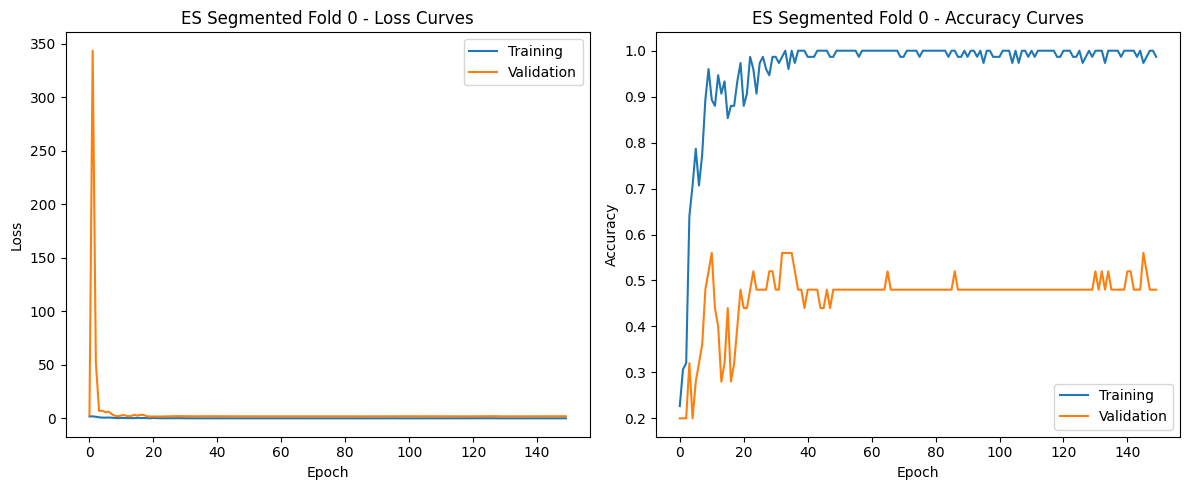


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.5000    0.8000    0.6154         5
         DCM     1.0000    0.8000    0.8889         5
         HCM     0.4545    1.0000    0.6250         5
          MI     0.0000    0.0000    0.0000         5
         NOR     0.5000    0.2000    0.2857         5

    accuracy                         0.5600        25
   macro avg     0.4909    0.5600    0.4830        25
weighted avg     0.4909    0.5600    0.4830        25



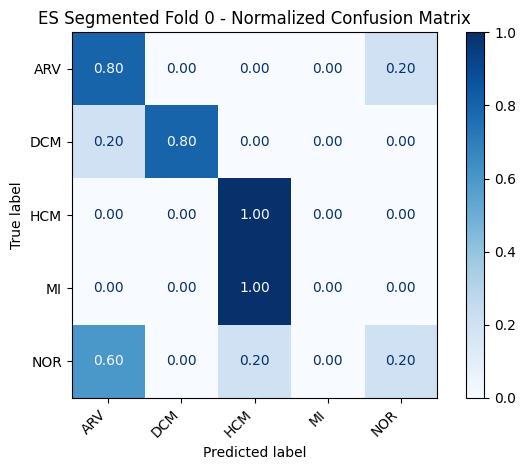


FOLD 1
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=21.33%  val_acc=20.00%  val_f1=6.67%
Epoch 002/150  train_acc=24.00%  val_acc=28.00%  val_f1=16.00%
Epoch 003/150  train_acc=45.33%  val_acc=32.00%  val_f1=23.71%
Epoch 004/150  train_acc=65.33%  val_acc=36.00%  val_f1=20.53%
Epoch 005/150  train_acc=60.00%  val_acc=40.00%  val_f1=33.10%
Epoch 006/150  train_acc=74.67%  val_acc=36.00%  val_f1=28.71%
Epoch 007/150  train_acc=78.67%  val_acc=20.00%  val_f1=6.67%
Epoch 008/150  train_acc=68.00%  val_acc=44.00%  val_f1=39.18%
Epoch 009/150  train_acc=86.67%  val_acc=48.00%  val_f1=42.38%
Epoch 010/150  train_acc=88.00%  val_acc=28.00%  val_f1=16.58%
Epoch 011/150  train_acc=84.00%  val_acc=60.00%  val_f1=59.00%
Epoch 012/150  train_acc=77.33%  val_acc=40.00%  val_f1=35.84%
Epoch 013/150  train_acc=85.33%  val_acc=52.00%  val_f1=45.27%
Epoch 014/150  train_acc=85.33%  val_acc=44.00%  val_f1=43.46%
Epoch 015/150  train_acc=78.67%  val_acc=48.00%  val_f1=41.11%
E

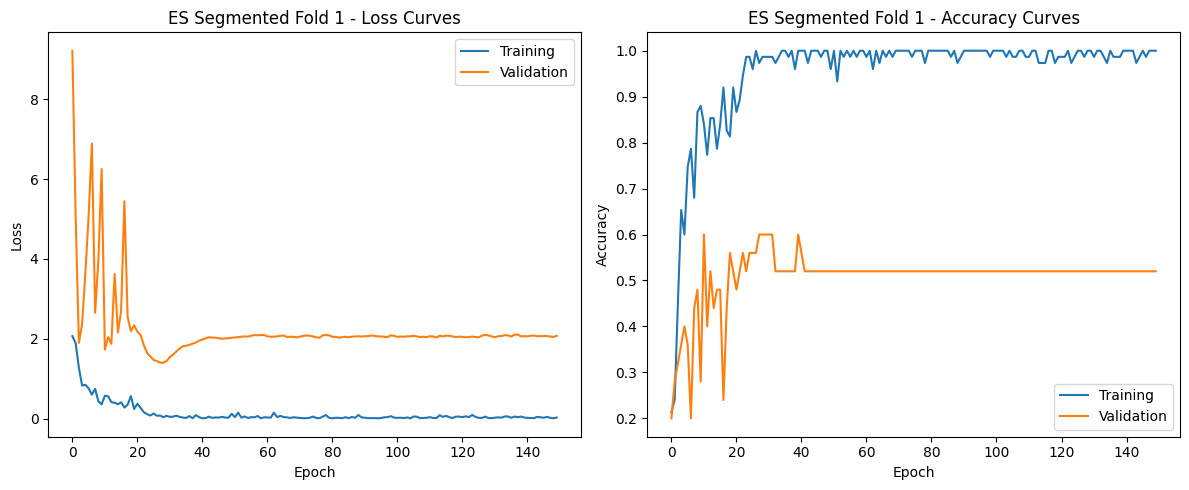


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.8000    0.8000    0.8000         5
         DCM     0.8333    1.0000    0.9091         5
         HCM     0.6000    0.6000    0.6000         5
          MI     0.2500    0.4000    0.3077         5
         NOR     1.0000    0.2000    0.3333         5

    accuracy                         0.6000        25
   macro avg     0.6967    0.6000    0.5900        25
weighted avg     0.6967    0.6000    0.5900        25



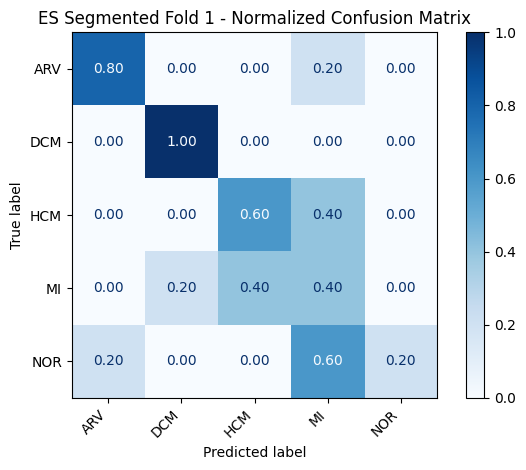


FOLD 2
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=29.33%  val_acc=20.00%  val_f1=7.14%
Epoch 002/150  train_acc=40.00%  val_acc=20.00%  val_f1=6.67%
Epoch 003/150  train_acc=36.00%  val_acc=16.00%  val_f1=5.71%
Epoch 004/150  train_acc=41.33%  val_acc=28.00%  val_f1=17.41%
Epoch 005/150  train_acc=53.33%  val_acc=20.00%  val_f1=6.67%
Epoch 006/150  train_acc=54.67%  val_acc=32.00%  val_f1=24.76%
Epoch 007/150  train_acc=74.67%  val_acc=48.00%  val_f1=41.11%
Epoch 008/150  train_acc=73.33%  val_acc=40.00%  val_f1=35.71%
Epoch 009/150  train_acc=77.33%  val_acc=56.00%  val_f1=49.19%
Epoch 010/150  train_acc=78.67%  val_acc=44.00%  val_f1=35.70%
Epoch 011/150  train_acc=86.67%  val_acc=44.00%  val_f1=35.96%
Epoch 012/150  train_acc=88.00%  val_acc=60.00%  val_f1=58.97%
Epoch 013/150  train_acc=88.00%  val_acc=44.00%  val_f1=38.86%
Epoch 014/150  train_acc=85.33%  val_acc=40.00%  val_f1=38.48%
Epoch 015/150  train_acc=86.67%  val_acc=68.00%  val_f1=61.13%
Epo

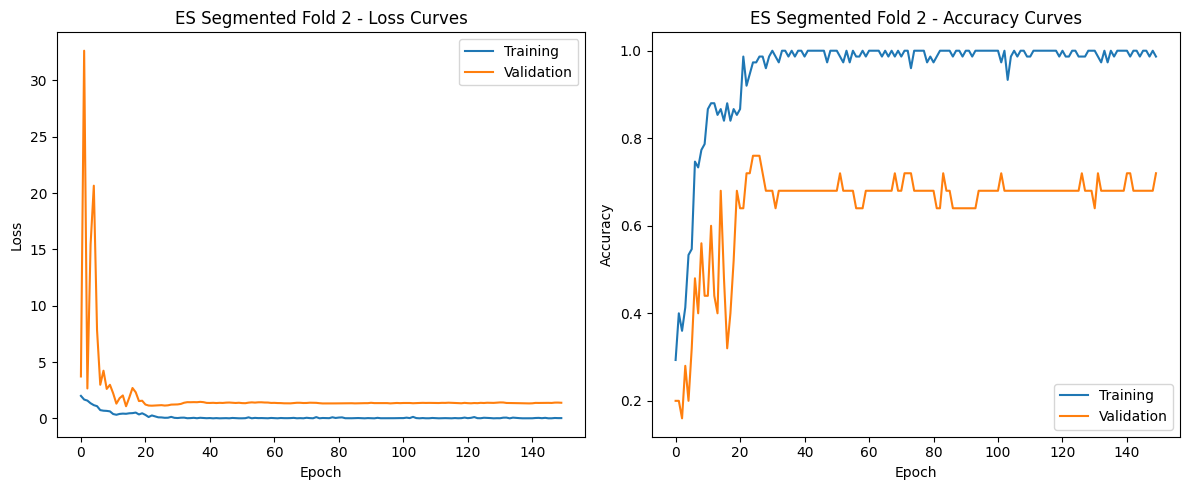


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.8333    1.0000    0.9091         5
         DCM     1.0000    0.8000    0.8889         5
         HCM     1.0000    0.8000    0.8889         5
          MI     0.6667    0.4000    0.5000         5
         NOR     0.5000    0.8000    0.6154         5

    accuracy                         0.7600        25
   macro avg     0.8000    0.7600    0.7605        25
weighted avg     0.8000    0.7600    0.7605        25



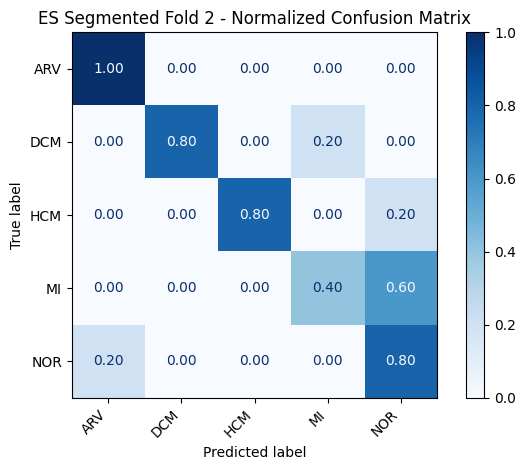


FOLD 3
Training samples   : 75
Validation samples : 25
Epoch 001/150  train_acc=20.00%  val_acc=20.00%  val_f1=6.67%
Epoch 002/150  train_acc=30.67%  val_acc=20.00%  val_f1=6.67%
Epoch 003/150  train_acc=44.00%  val_acc=20.00%  val_f1=11.33%
Epoch 004/150  train_acc=52.00%  val_acc=24.00%  val_f1=15.45%
Epoch 005/150  train_acc=61.33%  val_acc=32.00%  val_f1=23.05%
Epoch 006/150  train_acc=73.33%  val_acc=44.00%  val_f1=32.08%
Epoch 007/150  train_acc=77.33%  val_acc=44.00%  val_f1=33.33%
Epoch 008/150  train_acc=80.00%  val_acc=40.00%  val_f1=36.90%
Epoch 009/150  train_acc=81.33%  val_acc=44.00%  val_f1=37.71%
Epoch 010/150  train_acc=81.33%  val_acc=56.00%  val_f1=51.23%
Epoch 011/150  train_acc=84.00%  val_acc=56.00%  val_f1=50.43%
Epoch 012/150  train_acc=90.67%  val_acc=56.00%  val_f1=49.31%
Epoch 013/150  train_acc=80.00%  val_acc=56.00%  val_f1=50.00%
Epoch 014/150  train_acc=88.00%  val_acc=48.00%  val_f1=45.21%
Epoch 015/150  train_acc=80.00%  val_acc=56.00%  val_f1=57.84%
E

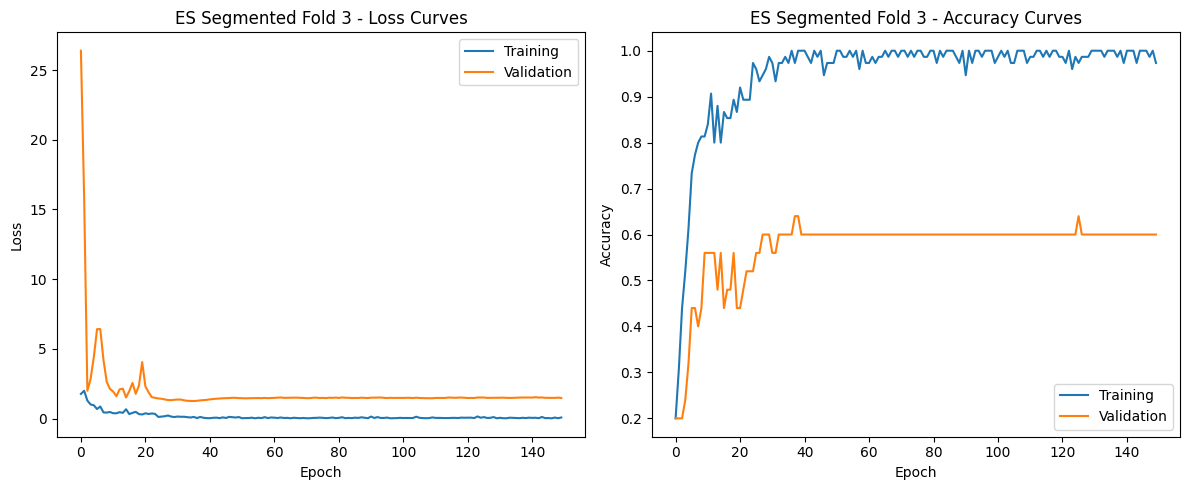


Classification Report (Validation Set, Best Checkpoint):
              precision    recall  f1-score   support

         ARV     0.6000    0.6000    0.6000         5
         DCM     0.6667    0.8000    0.7273         5
         HCM     0.6667    0.8000    0.7273         5
          MI     0.4000    0.4000    0.4000         5
         NOR     1.0000    0.6000    0.7500         5

    accuracy                         0.6400        25
   macro avg     0.6667    0.6400    0.6409        25
weighted avg     0.6667    0.6400    0.6409        25



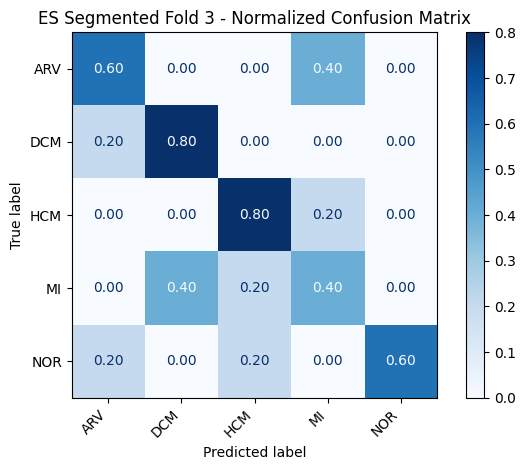


ES SEGMENTATION-GUIDED TRAINING SUMMARY (4 FOLDS, V5)
Fold 0 | Val Acc =  56.00% | Macro F1 =  48.30% | Macro Sens =  56.00% | Macro Spec =  89.00%
Fold 1 | Val Acc =  60.00% | Macro F1 =  59.00% | Macro Sens =  60.00% | Macro Spec =  90.00%
Fold 2 | Val Acc =  76.00% | Macro F1 =  76.05% | Macro Sens =  76.00% | Macro Spec =  94.00%
Fold 3 | Val Acc =  64.00% | Macro F1 =  64.09% | Macro Sens =  64.00% | Macro Spec =  91.00%

Mean ± Std across folds
Accuracy         : 64.00 ± 8.64
Macro F1-score   : 61.86 ± 11.52
Macro sensitivity: 64.00 ± 8.64
Macro specificity: 91.00 ± 2.16


In [11]:
import os
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    recall_score
)

# ===================== DEVICE =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===================== CLASS NAMES =====================
class_names_ES = CLASS_NAMES
print("Classes:", class_names_ES)

# ===================== OUTPUT DIRS =====================
CKPT_DIR = "./checkpoints_ES_segmented_v5"
FIG_DIR = "./figures_ES_segmented_v5"
META_DIR = "./fold_meta_ES_segmented_v5"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# ===================== TRAINING PARAMETERS =====================
num_epochs = 150
batch_size = 20
num_classes = 5
initial_lr = 1e-3

results_val_acc_ES_segmented_v5 = {}
results_val_f1macro_ES_segmented_v5 = {}
results_val_sensmacro_ES_segmented_v5 = {}
results_val_specmacro_ES_segmented_v5 = {}

print("\nStarting 4-fold training for ES segmentation-guided model (V5)...\n")

# ===================== HELPER: MACRO SPECIFICITY =====================
def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)
    return float(np.mean(specs))


# ===================== MAIN TRAINING LOOP =====================
for fold in range(4):
    print(f"\n{'='*80}")
    print(f"FOLD {fold}")
    print(f"{'='*80}")
    print(f"Training samples   : {len(fold_train_dataset_ES[fold])}")
    print(f"Validation samples : {len(fold_val_dataset_ES[fold])}")

    trainloader = DataLoader(
        fold_train_dataset_ES[fold],
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    valloader = DataLoader(
        fold_val_dataset_ES[fold],
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    dataloaders = {
        "train": trainloader,
        "val": valloader
    }

    dataset_sizes = {
        "train": len(fold_train_dataset_ES[fold]),
        "val": len(fold_val_dataset_ES[fold])
    }

    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    best_val_f1 = 0.0
    best_val_sens = 0.0
    best_val_spec = 0.0
    best_epoch = -1

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    # ===================== EPOCH LOOP =====================
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1:03d}/{num_epochs}", end="  ")

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            y_true_all = []
            y_pred_all = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * labels.size(0)
                running_corrects += torch.sum(preds == labels.data)

                y_true_all.extend(labels.detach().cpu().numpy().tolist())
                y_pred_all.extend(preds.detach().cpu().numpy().tolist())

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double().item() / dataset_sizes[phase]

            if phase == "train":
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc)
                print(f"train_acc={epoch_acc*100:.2f}%", end="  ")
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc)

                val_f1_macro = f1_score(y_true_all, y_pred_all, average="macro")
                val_sens_macro = recall_score(y_true_all, y_pred_all, average="macro", zero_division=0)
                val_spec_macro = macro_specificity_score(y_true_all, y_pred_all, num_classes=num_classes)

                # PAPER-STYLE ES LOGIC: save best checkpoint by validation accuracy
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_val_f1 = val_f1_macro
                    best_val_sens = val_sens_macro
                    best_val_spec = val_spec_macro
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())

                    ckpt_path = os.path.join(
                        CKPT_DIR,
                        f"ES-segmented-resnet50-best-fold-{fold}_v5.pth"
                    )
                    torch.save(best_model_wts, ckpt_path)

                print(f"val_acc={epoch_acc*100:.2f}%  val_f1={val_f1_macro*100:.2f}%")

    # ===================== LOAD BEST CHECKPOINT =====================
    model.load_state_dict(best_model_wts)

    results_val_acc_ES_segmented_v5[fold] = float(best_val_acc * 100)
    results_val_f1macro_ES_segmented_v5[fold] = float(best_val_f1 * 100)
    results_val_sensmacro_ES_segmented_v5[fold] = float(best_val_sens * 100)
    results_val_specmacro_ES_segmented_v5[fold] = float(best_val_spec * 100)

    # ===================== SAVE METADATA =====================
    fold_meta = {
        "fold": fold,
        "model_selection_metric_within_fold": "validation_accuracy",
        "best_epoch": int(best_epoch),
        "best_val_accuracy": float(best_val_acc * 100),
        "best_val_macro_f1": float(best_val_f1 * 100),
        "best_val_macro_sensitivity": float(best_val_sens * 100),
        "best_val_macro_specificity": float(best_val_spec * 100),
        "checkpoint_path": os.path.join(
            CKPT_DIR,
            f"ES-segmented-resnet50-best-fold-{fold}_v5.pth"
        )
    }

    with open(os.path.join(META_DIR, f"ES_segmented_fold_{fold}_meta_v5.json"), "w", encoding="utf-8") as f:
        json.dump(fold_meta, f, indent=2)

    print("\nBest fold checkpoint summary")
    print(f"Best epoch              : {best_epoch}")
    print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
    print(f"Best validation macro F1: {best_val_f1*100:.2f}%")
    print(f"Best validation macro sensitivity: {best_val_sens*100:.2f}%")
    print(f"Best validation macro specificity: {best_val_spec*100:.2f}%")

    # ===================== CURVES =====================
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(train_loss_history, label="Training")
    axs[0].plot(val_loss_history, label="Validation")
    axs[0].set_title(f"ES Segmented Fold {fold} - Loss Curves")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()

    axs[1].plot(train_acc_history, label="Training")
    axs[1].plot(val_acc_history, label="Validation")
    axs[1].set_title(f"ES Segmented Fold {fold} - Accuracy Curves")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ES_segmented_fold{fold}_loss_accuracy_curves_v5.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # ===================== VALIDATION REPORT =====================
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu()

            y_true_all.extend(labels.tolist())
            y_pred_all.extend(preds.tolist())

    print("\nClassification Report (Validation Set, Best Checkpoint):")
    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=class_names_ES,
        digits=4,
        zero_division=0
    ))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_true_all,
        y_pred_all,
        display_labels=class_names_ES,
        cmap=plt.cm.Blues,
        normalize="true",
        values_format=".2f"
    )
    disp.ax_.set_title(f"ES Segmented Fold {fold} - Normalized Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"ES_segmented_fold{fold}_normalized_confusion_matrix_v5.png"), dpi=300, bbox_inches="tight")
    plt.show()

# ===================== FINAL SUMMARY =====================
print("\n" + "="*90)
print("ES SEGMENTATION-GUIDED TRAINING SUMMARY (4 FOLDS, V5)")
print("="*90)

for f in range(4):
    print(
        f"Fold {f} | "
        f"Val Acc = {results_val_acc_ES_segmented_v5[f]:6.2f}% | "
        f"Macro F1 = {results_val_f1macro_ES_segmented_v5[f]:6.2f}% | "
        f"Macro Sens = {results_val_sensmacro_ES_segmented_v5[f]:6.2f}% | "
        f"Macro Spec = {results_val_specmacro_ES_segmented_v5[f]:6.2f}%"
    )

acc_values = np.array(list(results_val_acc_ES_segmented_v5.values()))
f1_values = np.array(list(results_val_f1macro_ES_segmented_v5.values()))
sens_values = np.array(list(results_val_sensmacro_ES_segmented_v5.values()))
spec_values = np.array(list(results_val_specmacro_ES_segmented_v5.values()))

print("\nMean ± Std across folds")
print(f"Accuracy         : {acc_values.mean():.2f} ± {acc_values.std(ddof=1):.2f}")
print(f"Macro F1-score   : {f1_values.mean():.2f} ± {f1_values.std(ddof=1):.2f}")
print(f"Macro sensitivity: {sens_values.mean():.2f} ± {sens_values.std(ddof=1):.2f}")
print(f"Macro specificity: {spec_values.mean():.2f} ± {spec_values.std(ddof=1):.2f}")

### 5. Final Evaluation of the ES Single-Phase Model  
**Held-Out Test Set Performance**

#### Overview
This section evaluates the final ES single-phase classification model on the official held-out test set.

#### Model Selection Strategy
- The selected ES configuration is **ResNet-50 with Adam and an initial learning rate of 0.001**
- Four fold-specific models are available from cross-validation training
- The final model is selected using the **highest validation macro F1-score** among the four folds
- The test set is used only for the final evaluation of the selected fold

#### Evaluation Outputs
- overall test accuracy
- macro F1-score
- macro sensitivity
- macro specificity
- full classification report
- normalized confusion matrix
- bootstrap summary based on 1000 resamples

#### Purpose
The goal of this stage is to measure how well the final ES model generalizes to previously unseen subjects in the held-out test set.

Validation macro F1-score per fold:
Fold 0: 48.30%
Fold 1: 59.00%
Fold 2: 76.05%
Fold 3: 64.09%

Selected fold for final ES segmented test evaluation: Fold 2
Selection criterion: highest validation macro F1-score = 76.05%
Loading checkpoint: checkpoints_ES_segmented_v5\ES-segmented-resnet50-best-fold-2_v5.pth

=== SINGLE RUN ON TEST SET (50 subjects) ===
Accuracy          : 60.00%
Macro F1-score    : 59.99%
Macro Sensitivity : 60.00%
Macro Specificity : 90.00%

Classification Report (Test Set):
              precision    recall  f1-score   support

         ARV     0.5000    0.4000    0.4444        10
         DCM     1.0000    0.5000    0.6667        10
         HCM     0.5714    0.8000    0.6667        10
          MI     0.7000    0.7000    0.7000        10
         NOR     0.4615    0.6000    0.5217        10

    accuracy                         0.6000        50
   macro avg     0.6466    0.6000    0.5999        50
weighted avg     0.6466    0.6000    0.5999        50



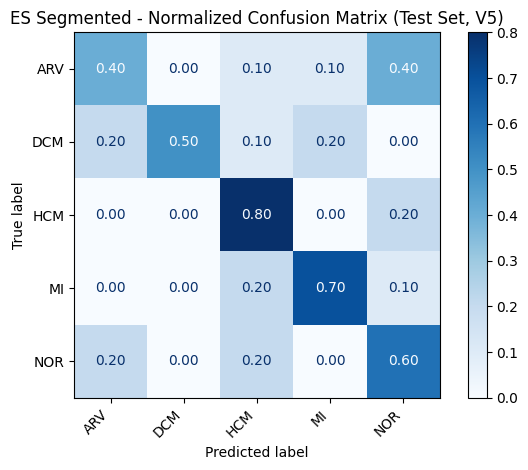

In [12]:
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)
import matplotlib.pyplot as plt

# ===================== DEVICE =====================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5

# ===================== CHECKPOINT DIR =====================
CKPT_DIR = Path("./checkpoints_ES_segmented_v5")

# ===================== HELPER =====================
def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))

# ===================== SELECT FINAL FOLD BY VALIDATION MACRO F1 =====================
best_fold = max(results_val_f1macro_ES_segmented_v5, key=results_val_f1macro_ES_segmented_v5.get)

print("Validation macro F1-score per fold:")
for f in sorted(results_val_f1macro_ES_segmented_v5.keys()):
    print(f"Fold {f}: {results_val_f1macro_ES_segmented_v5[f]:.2f}%")

print(f"\nSelected fold for final ES segmented test evaluation: Fold {best_fold}")
print(f"Selection criterion: highest validation macro F1-score = {results_val_f1macro_ES_segmented_v5[best_fold]:.2f}%")

# ===================== TEST LOADER =====================
testloader_ES = DataLoader(
    fold_test_dataset_ES[best_fold],
    batch_size=25,
    shuffle=False,
    num_workers=0
)

# ===================== LOAD MODEL =====================
ckpt_path = CKPT_DIR / f"ES-segmented-resnet50-best-fold-{best_fold}_v5.pth"
print("Loading checkpoint:", ckpt_path)

if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

model_ES = models.resnet50(weights="IMAGENET1K_V1")
model_ES.fc = nn.Linear(model_ES.fc.in_features, NUM_CLASSES)
model_ES.load_state_dict(torch.load(ckpt_path, map_location=device))
model_ES = model_ES.to(device)
model_ES.eval()

# ===================== EVALUATION =====================
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in testloader_ES:
        inputs = inputs.to(device)
        outputs = model_ES(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred) * 100
macro_f1 = f1_score(y_true, y_pred, average="macro") * 100
macro_spec = macro_specificity_score(y_true, y_pred, num_classes=NUM_CLASSES) * 100
macro_sens = recall_score(y_true, y_pred, average="macro", zero_division=0) * 100

print("\n=== SINGLE RUN ON TEST SET (50 subjects) ===")
print(f"Accuracy          : {acc:.2f}%")
print(f"Macro F1-score    : {macro_f1:.2f}%")
print(f"Macro Sensitivity : {macro_sens:.2f}%")
print(f"Macro Specificity : {macro_spec:.2f}%")

print("\nClassification Report (Test Set):")
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=CLASS_NAMES,
    cmap=plt.cm.Blues,
    normalize="true",
    values_format=".2f"
)
disp.ax_.set_title("ES Segmented - Normalized Confusion Matrix (Test Set, V5)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ES_segmented_test_normalized_confusion_matrix_v5.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix

# ===================== BOOTSTRAP PARAMETERS =====================
n_bootstrap = 1000
rng = np.random.default_rng(seed=42)

bootstrap_acc = []
bootstrap_f1 = []
bootstrap_sens = []
bootstrap_spec = []

def macro_specificity_score(y_true, y_pred, num_classes=5):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    specs = []

    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        denom = tn + fp
        spec = tn / denom if denom > 0 else 0.0
        specs.append(spec)

    return float(np.mean(specs))

print("\nRunning bootstrap resampling (n=1000)...")

n = len(y_true)

for _ in range(n_bootstrap):

    idx = rng.integers(0, n, n)

    y_true_bs = y_true[idx]
    y_pred_bs = y_pred[idx]

    acc = accuracy_score(y_true_bs, y_pred_bs) * 100
    f1 = f1_score(y_true_bs, y_pred_bs, average="macro") * 100
    sens = recall_score(y_true_bs, y_pred_bs, average="macro", zero_division=0) * 100
    spec = macro_specificity_score(y_true_bs, y_pred_bs) * 100

    bootstrap_acc.append(acc)
    bootstrap_f1.append(f1)
    bootstrap_sens.append(sens)
    bootstrap_spec.append(spec)

bootstrap_acc = np.array(bootstrap_acc)
bootstrap_f1 = np.array(bootstrap_f1)
bootstrap_sens = np.array(bootstrap_sens)
bootstrap_spec = np.array(bootstrap_spec)

print("\n=== BOOTSTRAP TEST RESULTS (n=1000) ===")
print(f"Accuracy          : {bootstrap_acc.mean():.2f} ± {bootstrap_acc.std():.2f}   (min {bootstrap_acc.min():.2f} / max {bootstrap_acc.max():.2f})")
print(f"Macro F1-score    : {bootstrap_f1.mean():.2f} ± {bootstrap_f1.std():.2f}   (min {bootstrap_f1.min():.2f} / max {bootstrap_f1.max():.2f})")
print(f"Macro Sensitivity : {bootstrap_sens.mean():.2f} ± {bootstrap_sens.std():.2f}   (min {bootstrap_sens.min():.2f} / max {bootstrap_sens.max():.2f})")
print(f"Macro Specificity : {bootstrap_spec.mean():.2f} ± {bootstrap_spec.std():.2f}   (min {bootstrap_spec.min():.2f} / max {bootstrap_spec.max():.2f})")


Running bootstrap resampling (n=1000)...

=== BOOTSTRAP TEST RESULTS (n=1000) ===
Accuracy          : 60.16 ± 6.81   (min 36.00 / max 80.00)
Macro F1-score    : 58.85 ± 6.91   (min 37.87 / max 80.08)
Macro Sensitivity : 60.41 ± 6.72   (min 39.18 / max 82.05)
Macro Specificity : 90.07 ± 1.70   (min 83.73 / max 95.02)
